In [ ]:
import pickle
import cv2
import numpy as np
from matplotlib import pyplot as plt

with open('../../ETL/data/pickles/processed.pkl', 'rb') as file:
	data = pickle.load(file)
with open('../../ETL/data/pickles/patches.pkl', 'rb') as file:
	patches = pickle.load(file)

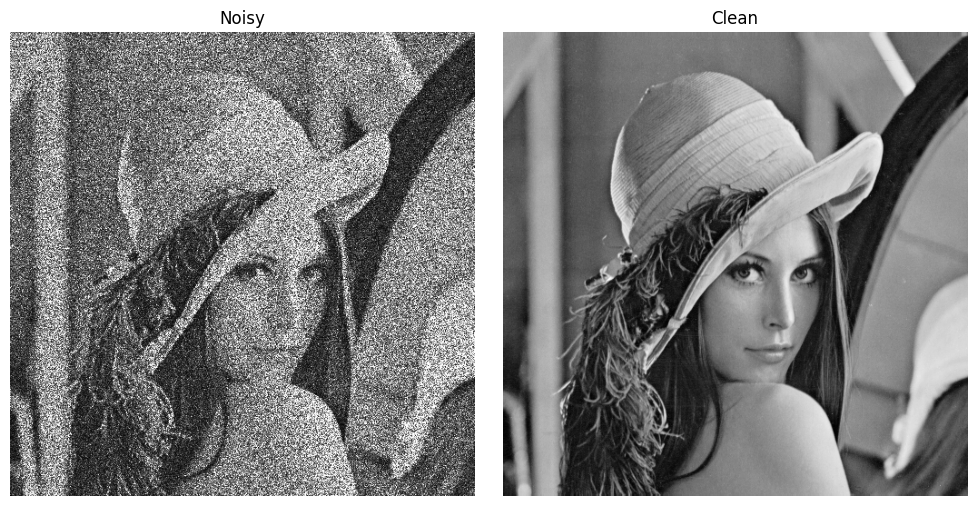

Image shape: (512, 512)
Noisy Image shape: (512, 512)
Image mean: 0.48473498
Noisy Image mean: 0.45580152
Image std: 0.18799537
Noisy Image std: 0.28220677


In [68]:
i = 5
img = data['set12']['clean'][i]
noisy_img = data['set12']['noisy'][i]

# let's visualise the images with cv2, the images are in numpy array format np.float32 between 0 and 1
plt.figure(figsize=(10,5))
# Noisy
plt.subplot(1, 2, 1)
plt.imshow(noisy_img, cmap='gray')
plt.title("Noisy")
plt.axis("off")
# Clean
plt.subplot(1, 2, 2)
plt.imshow(img, cmap='gray')
plt.title("Clean")
plt.axis("off")

plt.tight_layout()
plt.show()
print("Image shape:", img.shape)
print("Noisy Image shape:", noisy_img.shape)
print("Image mean:", np.mean(img))
print("Noisy Image mean:", np.mean(noisy_img))
print("Image std:", np.std(img))
print("Noisy Image std:", np.std(noisy_img))

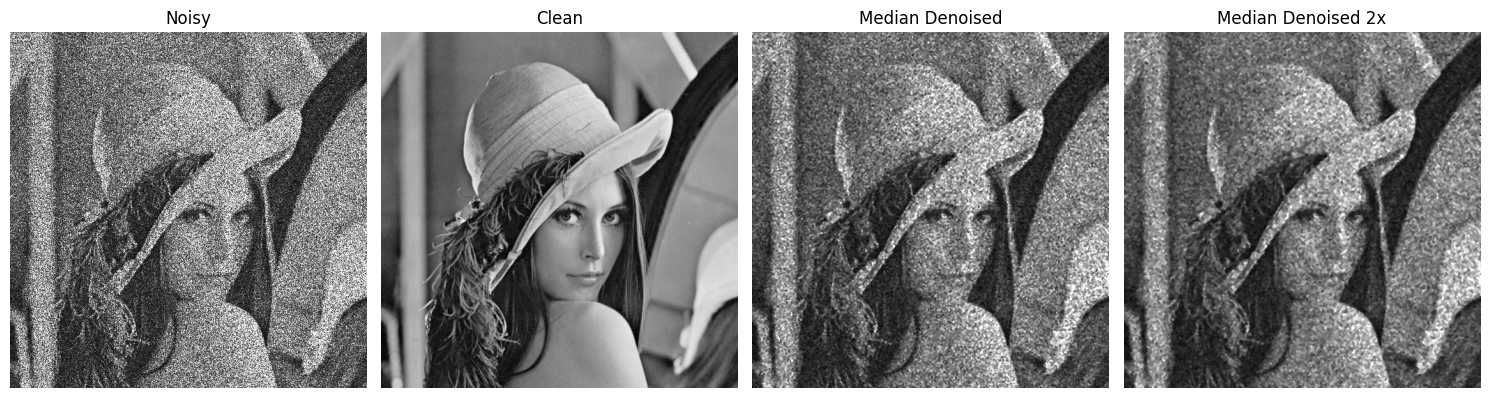

In [69]:
# conversion → uint8
noisy_8 = (noisy_img * 255).astype(np.uint8)

# filtre médian (k=3,5,7…)
k = 3
denoised_8 = cv2.medianBlur(noisy_8, k)
denoised_8_1 = cv2.medianBlur(denoised_8, k)

# retour float32 [0,1]
denoised = denoised_8.astype(np.float32) / 255.0
denoised_1 = denoised_8_1.astype(np.float32) / 255.0


plt.figure(figsize=(15,5))

# Noisy
plt.subplot(1, 4, 1)
plt.imshow(noisy_img, cmap='gray')
plt.title("Noisy")
plt.axis("off")

# Original (clean)
plt.subplot(1, 4, 2)
plt.imshow(img, cmap='gray')
plt.title("Clean")
plt.axis("off")

# Denoised (median)
plt.subplot(1, 4, 3)
plt.imshow(denoised, cmap='gray')
plt.title("Median Denoised")
plt.axis("off")

# Denoised (median, second pass)
plt.subplot(1, 4, 4)
plt.imshow(denoised_1, cmap='gray')
plt.title("Median Denoised 2x")
plt.axis("off")

plt.tight_layout()
plt.show()


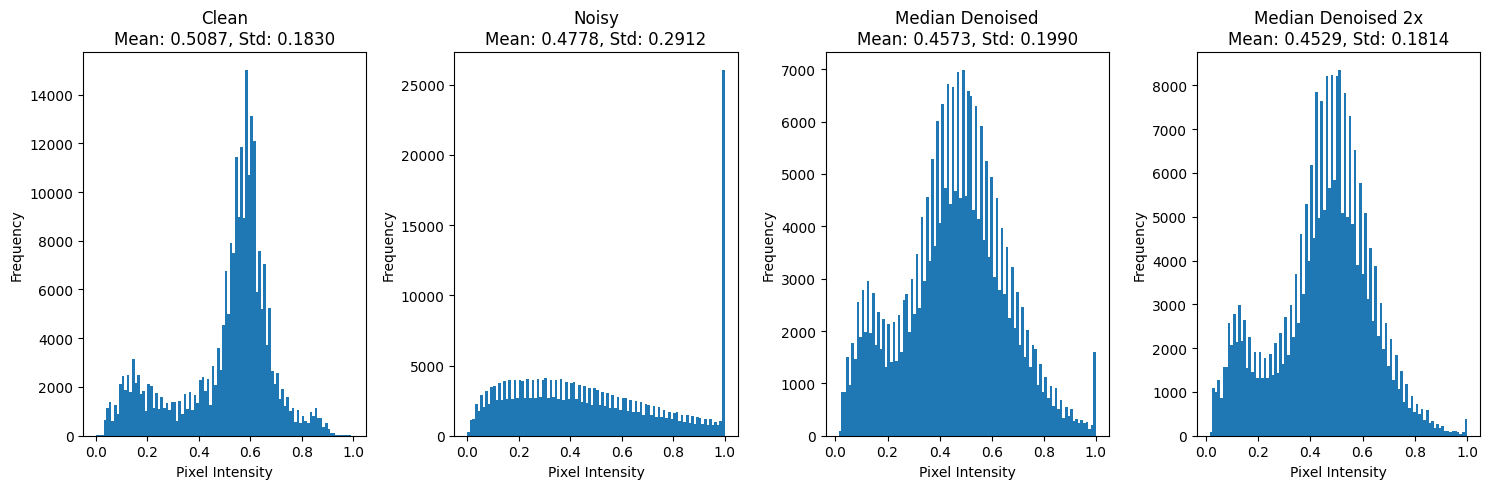

In [58]:
# let's study the mean, std and histogram of original, noisy and denoised images
def plot_image_stats(images, titles):
	plt.figure(figsize=(15,5))
	for i, img in enumerate(images):
		mean = np.mean(img)
		std = np.std(img)
		plt.subplot(1, len(images), i+1)
		plt.hist(img.ravel(), bins=100)
		plt.title(f"{titles[i]}\nMean: {mean:.4f}, Std: {std:.4f}")
		plt.xlabel("Pixel Intensity")
		plt.ylabel("Frequency")
	plt.tight_layout()
	plt.show()
plot_image_stats([img, noisy_img, denoised, denoised_1], ["Clean", "Noisy", "Median Denoised", "Median Denoised 2x"])#!/usr/bin/env python3